# Segmentación de Clientes Retail con K-Means y t-SNE

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · No Supervisado · Clustering · K-Means + t-SNE

---

### Objetivo

Segmentar a **6.457 clientes** de una cadena de electrónica de consumo en grupos con comportamiento de compra similar usando **K-Means**, y usar **t-SNE** para visualizar en 2 dimensiones una relación de 9 variables que sería imposible de interpretar en un gráfico convencional.

### Contexto de negocio

**El cliente:** una cadena de tiendas de electrónica de consumo (tipo MediaMarkt) con canal online y físico.

**El problema:** el equipo de marketing trata a toda la base de clientes por igual. No hay una forma sistemática de distinguir al comprador ocasional de bajo ticket del cliente de alto valor que compra con frecuencia, ni de dirigir el presupuesto de retención a quien realmente lo necesita.

**La pregunta:** ¿existen grupos naturales de clientes según su comportamiento de compra (gasto, frecuencia, canal, antigüedad de la última compra), y se pueden visualizar y describir de forma que un responsable de marketing los entienda de un vistazo?

## 1. Setup: librerías y configuración visual

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.rcParams["figure.figsize"] = (8, 5)

## 2. Carga de datos

In [2]:
df = pd.read_excel("clientes_mediamarkt.xlsx")

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

df.head()

Filas: 6457
Columnas: 26


,Customer_ID,Customer_Profile,Age,Annual_Income,Customer_Tenure,Total_Purchases,Average_Ticket,Total_Spending,Online_Purchases,Store_Purchases,...,Extended_Warranties,Financing_Contracts,Returns,Coupons_Used,Website_Visits,Emails_Opened,Marketing_Clicks,Days_Since_Last_Purchase,Loyalty_Points,Satisfaction
0,1,3,34,49072,5,13,271.99,4322.48,6,7,...,4,3,0,2,52,3,2,233,10062,5
1,2,5,60,33441,6,23,126.36,3548.86,21,2,...,3,2,1,9,189,28,15,152,8747,5
2,3,5,42,20302,4,18,67.69,1543.43,16,2,...,1,1,0,9,157,28,10,163,1872,5
3,4,2,43,85606,9,25,630.79,17449.74,19,6,...,6,8,0,2,167,27,8,124,42802,8
4,5,5,44,31539,6,23,117.14,2755.44,22,1,...,4,2,1,9,221,46,15,105,7749,4


El dataset incluye 26 variables por cliente: datos demográficos (`Age`, `Annual_Income`), comportamiento de compra (`Total_Purchases`, `Average_Ticket`, `Total_Spending`), canal (`Online_Purchases`, `Store_Purchases`), categorías de producto compradas, interacción con marketing (`Website_Visits`, `Emails_Opened`) y un campo `Customer_Profile` (valores 1 a 5) que corresponde a un perfil **ya asignado** en el dato de origen.

No se le da esa etiqueta al modelo: la dejamos aparte y la usamos solo al final, como control externo para comprobar si K-Means llega a conclusiones parecidas sin conocerla.

## 3. Análisis exploratorio

### Distribución de las variables numéricas

Para no arrastrar las 26 columnas al modelo (muchas son recuentos de categorías de producto que aportan más ruido que señal), trabajamos desde el principio con un subconjunto de 9 variables de comportamiento y valor de cliente — el mismo criterio RFM (Recencia, Frecuencia, Valor monetario) ampliado con variables de canal digital.

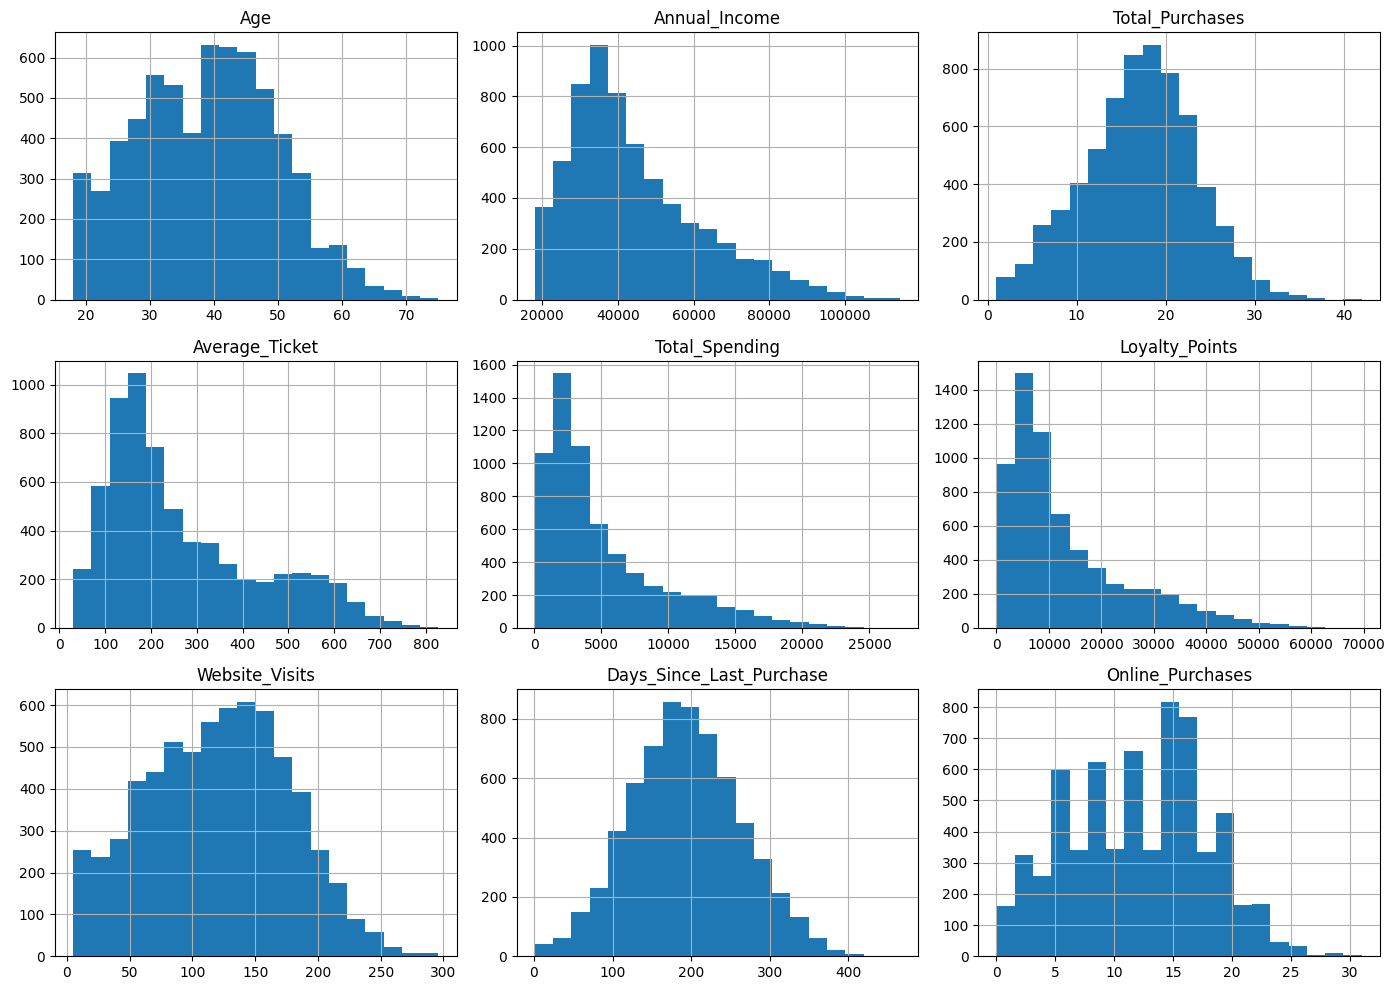

In [3]:
features = [
    "Age",
    "Annual_Income",
    "Total_Purchases",
    "Average_Ticket",
    "Total_Spending",
    "Loyalty_Points",
    "Website_Visits",
    "Days_Since_Last_Purchase",
    "Online_Purchases",
]

df[features].hist(bins=20, figsize=(14, 10))
plt.tight_layout()
plt.show()

**`Total_Spending`** y **`Loyalty_Points`** están claramente sesgadas a la derecha: la media de gasto (**5.107 €**) supera a la mediana (**3.433 €**), señal de un grupo pequeño de clientes que gasta mucho más que el resto. El resto de variables (`Age`, `Total_Purchases`, `Website_Visits`) tienen distribuciones razonablemente simétricas.

### Matriz de correlación

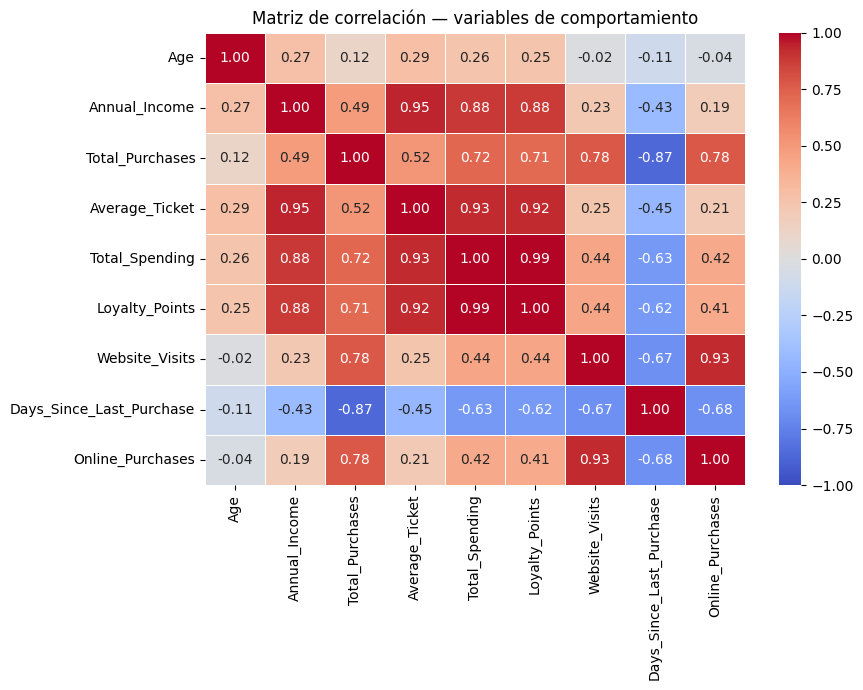

In [4]:
corr = df[features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Matriz de correlación — variables de comportamiento")
plt.tight_layout()
plt.show()

Hay **multicolinealidad fuerte** entre varias variables: `Total_Spending` y `Loyalty_Points` correlacionan al **0.99** (los puntos de fidelidad se acumulan proporcionalmente al gasto, así que son casi la misma información dos veces), `Average_Ticket` y `Annual_Income` al **0.95**, y `Online_Purchases` con `Website_Visits` al **0.93**. K-Means no exige variables independientes, pero esto explica por qué varias métricas se moverán juntas al segmentar: en la práctica, el modelo verá "una" dimensión de valor económico repetida tres veces.

## 4. Preprocesamiento

In [5]:
X = df[features].copy()
X_scaled = StandardScaler().fit_transform(X)

print("Valores nulos:", X.isnull().sum().sum())
print("Forma tras escalado:", X_scaled.shape)

Valores nulos: 0
Forma tras escalado: (6457, 9)


K-Means usa distancias euclídeas, así que estandarizamos con `StandardScaler`. Sin este paso, `Annual_Income` (rango ~18.000-114.000) o `Loyalty_Points` (rango 0-69.617) dominarían por completo sobre variables como `Age`, que aporta información real pero vive en una escala mucho más pequeña.

## 5. Visualización con t-SNE

Antes de segmentar, usamos **t-SNE** (*t-distributed Stochastic Neighbor Embedding*) para proyectar las 9 variables en 2 dimensiones y ver si existe estructura real en los datos — grupos separables — antes de forzar ningún número de clusters. A diferencia de PCA, t-SNE no busca conservar varianza global sino las distancias *locales* entre puntos cercanos, lo que suele producir mapas más legibles para detectar agrupaciones.

Usamos `perplexity=35` (en el rango recomendado de 5-50, escalado a los ~6.500 clientes del dataset) e `init="pca"`, que estabiliza el resultado frente a una inicialización aleatoria.

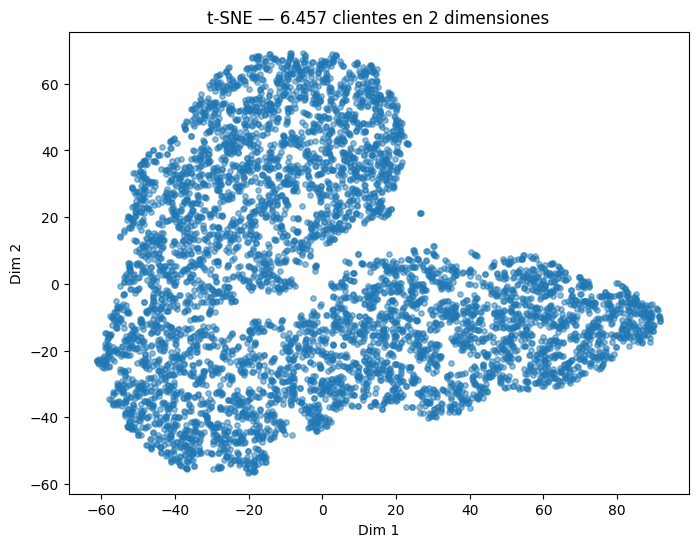

In [6]:
tsne = TSNE(
    n_components=2,
    perplexity=35,
    learning_rate="auto",
    init="pca",
    random_state=42,
)
Xt = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(Xt[:, 0], Xt[:, 1], alpha=0.5, s=15)
plt.title("t-SNE — 6.457 clientes en 2 dimensiones")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

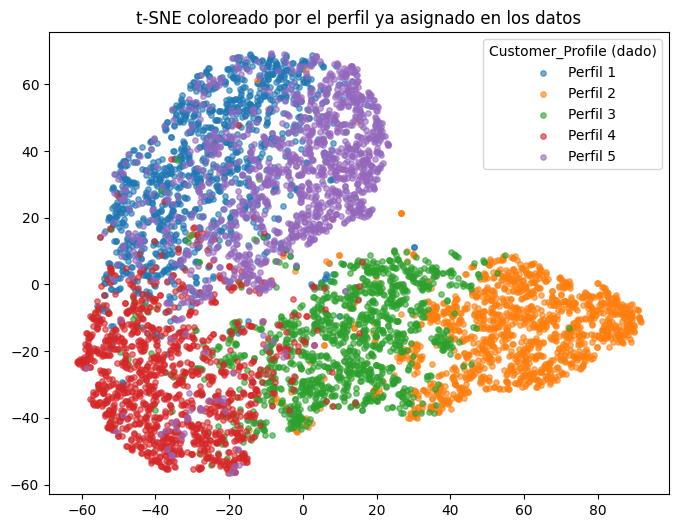

In [7]:
plt.figure(figsize=(8, 6))

for perfil in sorted(df["Customer_Profile"].unique()):
    mask = df["Customer_Profile"] == perfil
    plt.scatter(Xt[mask, 0], Xt[mask, 1], label=f"Perfil {perfil}", alpha=0.6, s=15)

plt.legend(title="Customer_Profile (dado)")
plt.title("t-SNE coloreado por el perfil ya asignado en los datos")
plt.show()

Al colorear por el `Customer_Profile` que ya venía en los datos, se ven zonas del mapa claramente dominadas por un único perfil — la estructura que t-SNE encuentra sin supervisión coincide, al menos parcialmente, con una segmentación que ya existía. Esto es una buena señal antes de aplicar K-Means: significa que hay grupos reales que descubrir, no solo ruido.

### ¿Qué representa cada eje de t-SNE?

In [8]:
tsne_df = pd.DataFrame(Xt, columns=["tSNE_1", "tSNE_2"], index=df.index)

analisis_tsne = pd.concat([X, tsne_df], axis=1)
correlaciones = analisis_tsne.corr()

correlaciones_tsne = correlaciones[["tSNE_1", "tSNE_2"]].drop(index=["tSNE_1", "tSNE_2"])
correlaciones_tsne["Importancia"] = correlaciones_tsne.abs().max(axis=1)
correlaciones_tsne = correlaciones_tsne.sort_values("Importancia", ascending=False)

correlaciones_tsne.round(3)

,tSNE_1,tSNE_2,Importancia
Total_Spending,0.897,-0.182,0.897
Loyalty_Points,0.893,-0.185,0.893
Average_Ticket,0.834,-0.375,0.834
Annual_Income,0.795,-0.360,0.795
Total_Purchases,0.777,0.408,0.777
Online_Purchases,0.521,0.714,0.714
Days_Since_Last_Purchase,-0.705,-0.389,0.705
Website_Visits,0.551,0.668,0.668
Age,0.469,-0.415,0.469


Las variables que más correlacionan con **tSNE_1** son `Total_Spending` (**0.90**), `Loyalty_Points` (**0.89**) y `Average_Ticket` (**0.83**): el primer eje ordena a los clientes de menor a mayor **valor económico**. El segundo eje, **tSNE_2**, está dominado por `Online_Purchases` (**0.71**) y `Days_Since_Last_Purchase` (**-0.71**): separa al cliente digital y activo del cliente que compra poco por internet y lleva tiempo sin volver. En otras palabras, el mapa resume 9 variables en dos preguntas: *"¿cuánto vale este cliente?"* y *"¿qué tan digital y activo es?"*.

## 6. Selección del número de clusters

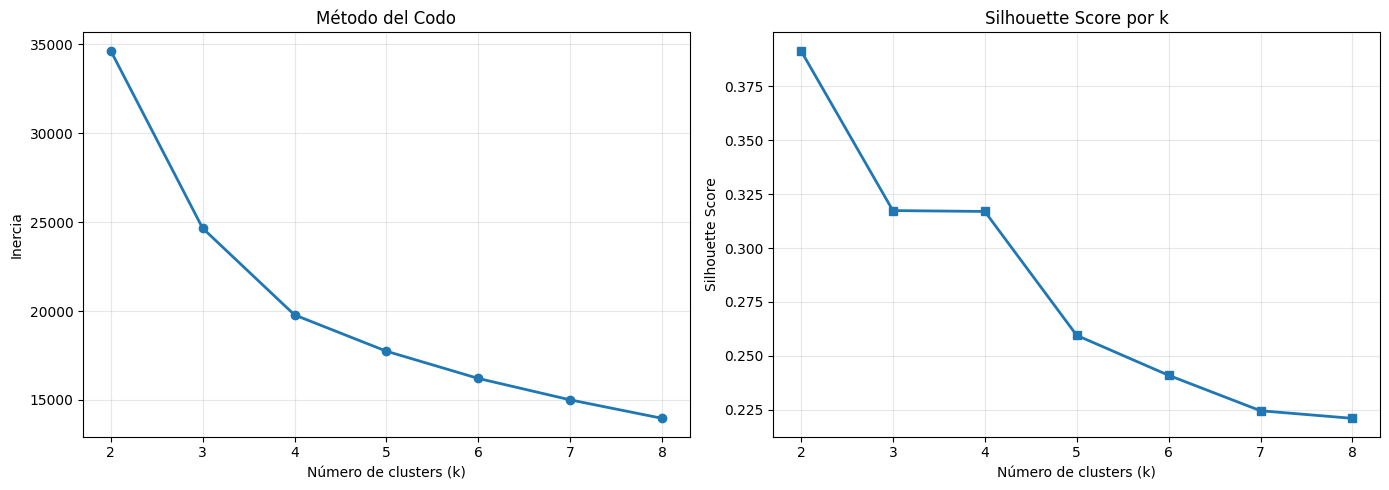

k=2 | Inercia=34647.2 | Silhouette=0.3914
k=3 | Inercia=24663.4 | Silhouette=0.3173
k=4 | Inercia=19784.2 | Silhouette=0.3169
k=5 | Inercia=17742.7 | Silhouette=0.2596
k=6 | Inercia=16211.4 | Silhouette=0.2411
k=7 | Inercia=15005.3 | Silhouette=0.2246
k=8 | Inercia=13966.7 | Silhouette=0.2211


In [9]:
K_range = range(2, 9)
inertias = []
silhouettes = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(K_range), inertias, marker="o", linewidth=2)
ax1.set_xlabel("Número de clusters (k)")
ax1.set_ylabel("Inercia")
ax1.set_title("Método del Codo")
ax1.set_xticks(list(K_range))
ax1.grid(True, alpha=0.3)

ax2.plot(list(K_range), silhouettes, marker="s", linewidth=2)
ax2.set_xlabel("Número de clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score por k")
ax2.set_xticks(list(K_range))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for k, inertia, sil in zip(K_range, inertias, silhouettes):
    print(f"k={k} | Inercia={inertia:.1f} | Silhouette={sil:.4f}")

### Decisión: k = 4

El silhouette score más alto se da en **k=2** (**0.39**), pero ese resultado es demasiado grueso para uso comercial: separaría solo "gasta poco" de "gasta mucho", sin distinguir canal ni frecuencia. A partir de k=3, el silhouette se estabiliza entre **0.32** y **0.32** (k=3 y k=4 prácticamente empatados) y baja progresivamente después.

Elegimos **k=4** porque, sin perder apenas calidad de separación frente a k=3, da al equipo de marketing cuatro perfiles accionables en vez de tres — la ganancia de granularidad no cuesta nada en calidad del cluster.

## 7. Modelo K-Means (k = 4)

In [10]:
N_CLUSTERS = 4

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df["KMeans_Profile"] = kmeans.fit_predict(X_scaled)

silhouette_final = silhouette_score(X_scaled, df["KMeans_Profile"])
print(f"Silhouette Score (k=4): {silhouette_final:.4f}")

Silhouette Score (k=4): 0.3169


## 8. Perfiles de los clusters

Cluster 0: 1863 clientes (28.9%)
Cluster 1: 2230 clientes (34.5%)
Cluster 2: 978 clientes (15.1%)
Cluster 3: 1386 clientes (21.5%)


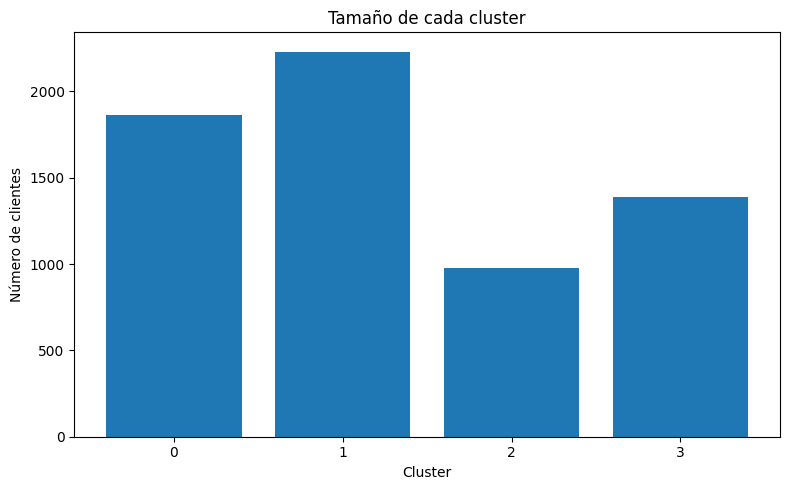

In [11]:
distribucion = df["KMeans_Profile"].value_counts().sort_index()

for cluster, cantidad in distribucion.items():
    porcentaje = cantidad / len(df) * 100
    print(f"Cluster {cluster}: {cantidad} clientes ({porcentaje:.1f}%)")

plt.figure(figsize=(8, 5))
plt.bar(distribucion.index.astype(str), distribucion.values)
plt.xlabel("Cluster")
plt.ylabel("Número de clientes")
plt.title("Tamaño de cada cluster")
plt.tight_layout()
plt.show()

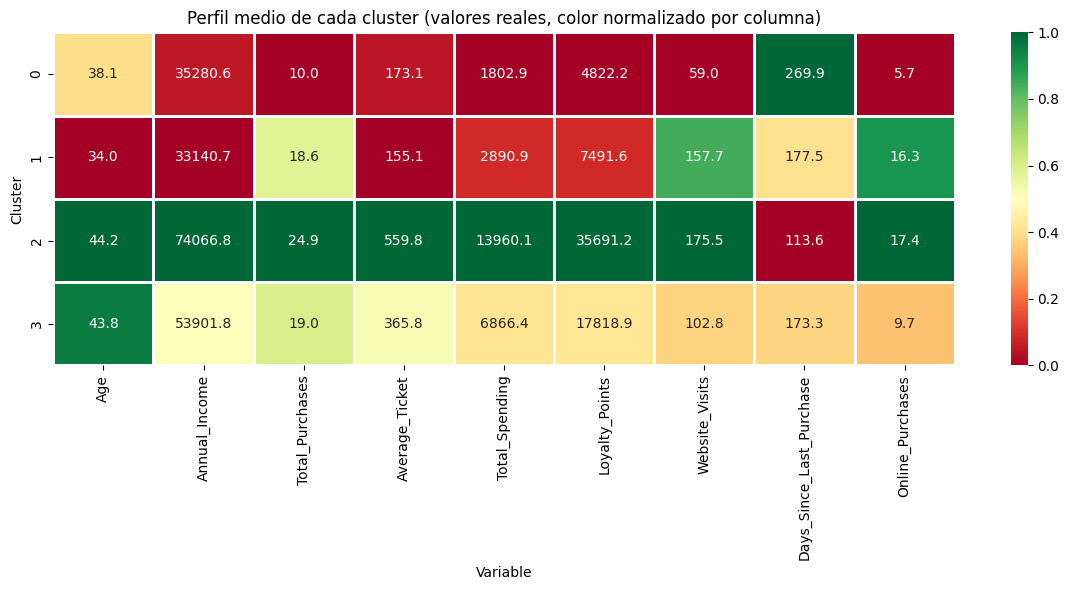

,Age,Annual_Income,Total_Purchases,Average_Ticket,Total_Spending,Loyalty_Points,Website_Visits,Days_Since_Last_Purchase,Online_Purchases
KMeans_Profile,,,,,,,,,
0,38.1,35280.6,10.0,173.1,1802.9,4822.2,59.0,269.9,5.7
1,34.0,33140.7,18.6,155.1,2890.9,7491.6,157.7,177.5,16.3
2,44.2,74066.8,24.9,559.8,13960.1,35691.2,175.5,113.6,17.4
3,43.8,53901.8,19.0,365.8,6866.4,17818.9,102.8,173.3,9.7


In [12]:
perfil = df.groupby("KMeans_Profile")[features].mean().round(1)

perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min())

plt.figure(figsize=(12, 6))
sns.heatmap(
    perfil_norm,
    annot=perfil,
    fmt=".1f",
    cmap="RdYlGn",
    linewidths=1,
    linecolor="white",
)
plt.title("Perfil medio de cada cluster (valores reales, color normalizado por columna)")
plt.xlabel("Variable")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

perfil

### Lectura de los perfiles

- **Cluster 2 — Clientes premium (978, 15.1%):** el más pequeño y, con diferencia, el de mayor valor: **13.960 €** de gasto medio, ticket medio de **560 €**, ingreso anual de **74.067 €** y la recencia más baja (**114 días** desde la última compra, el grupo más activo). Compran online y en tienda casi por igual.
- **Cluster 3 — Valor medio-alto, más de tienda física (1.386, 21.5%):** gasto medio **6.866 €**, ticket **366 €**. De sus **19** compras medias solo **9.7** son online (~51%) — el grupo menos digital de los cuatro, junto al 0.
- **Cluster 1 — Digital, joven y frecuente, ticket bajo (2.230, 34.5%):** el más numeroso. Edad media más baja (**34 años**), **16.3** de sus **18.6** compras son online (~88%), pero el ticket medio es el más bajo (**155 €**) y el gasto total moderado (**2.891 €**).
- **Cluster 0 — Bajo valor y en riesgo de abandono (1.863, 28.9%):** el gasto más bajo (**1.803 €**), la frecuencia de visitas a la web más baja (**59**) y, sobre todo, la recencia más alta: **270 días** de media desde la última compra — el doble que el cluster premium.

## 9. Clusters visualizados en el espacio t-SNE

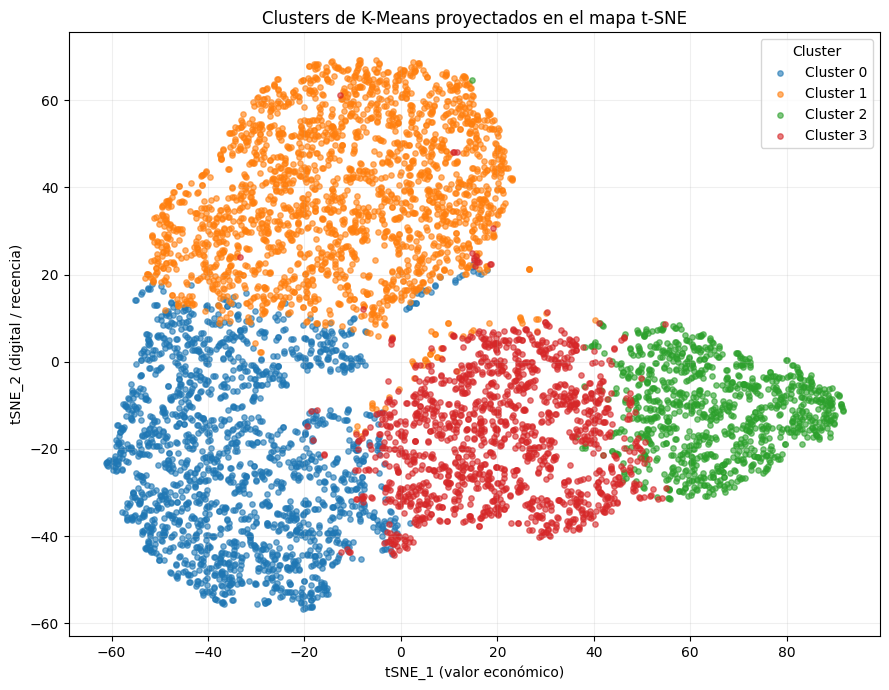

In [13]:
plt.figure(figsize=(9, 7))

for cluster in sorted(df["KMeans_Profile"].unique()):
    mask = df["KMeans_Profile"] == cluster
    plt.scatter(Xt[mask, 0], Xt[mask, 1], label=f"Cluster {cluster}", alpha=0.6, s=15)

plt.xlabel("tSNE_1 (valor económico)")
plt.ylabel("tSNE_2 (digital / recencia)")
plt.title("Clusters de K-Means proyectados en el mapa t-SNE")
plt.legend(title="Cluster")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Los cuatro clusters ocupan regiones bien diferenciadas del mapa, coherentes con los ejes que interpretamos antes: el cluster premium (2) se concentra en la zona de **tSNE_1** alto (mayor valor económico), y los clusters 0 y 1 se separan sobre todo en el eje **tSNE_2** (digital/recencia) más que en valor. Que K-Means y t-SNE — dos algoritmos con lógicas completamente distintas — lleguen a fronteras parecidas refuerza que la segmentación no es un artefacto del método, sino que responde a una estructura real de los datos.

## 10. Evaluación: ¿coincide con el perfil ya asignado en los datos?

El dataset traía un campo `Customer_Profile` (1 a 5) que no se usó para entrenar el modelo. Comparamos ahora, solo como control, si los 4 clusters de K-Means reconstruyen esa segmentación original.

In [14]:
pd.crosstab(df["KMeans_Profile"], df["Customer_Profile"])

Customer_Profile,1,2,3,4,5
KMeans_Profile,,,,,
0,236,9,217,1206,195
1,1063,13,42,18,1094
2,0,947,30,0,1
3,8,360,969,32,17


El resultado es honesto, no perfecto:

- El **cluster 2** (premium) recupera casi exactamente el **perfil 2** original: **947 de sus 978 clientes** (96.8%) pertenecen a ese perfil. K-Means, sin conocer la etiqueta, aísla solo con comportamiento el mismo grupo que el negocio ya identificaba como distinto.
- El **cluster 3** se corresponde mayoritariamente con el **perfil 3** (969 de 1.386, 69.9%), mezclado con parte del perfil 2.
- El **cluster 1**, en cambio, **no distingue** entre los perfiles 1 y 5 originales: los reparte casi al 50% (1.063 vs. 1.094 clientes). Esto sugiere que la diferencia entre esos dos perfiles no está en las 9 variables de comportamiento que usamos — probablemente depende de otras columnas del dataset (categorías de producto, satisfacción, devoluciones) que quedaron fuera del modelo a propósito.

La conclusión no es que el modelo falle, sino que **las variables de valor y canal explican parte, no toda, de la segmentación original** — un resultado más útil que si hubiera "cuadrado perfecto", porque señala exactamente qué información falta si se quiere reconstruir los 5 perfiles completos.

## 11. Conclusión

> **El hallazgo:** con solo 9 variables de comportamiento (gasto, frecuencia, canal, recencia), K-Means separa a los clientes en 4 grupos accionables y recupera de forma casi exacta (96.8%) el segmento premium que el negocio ya tenía identificado — sin haber visto esa etiqueta durante el entrenamiento.

**Recomendaciones:**

1. **Prioridad alta — activar el cluster 0 (1.863 clientes, 28.9%):** es el grupo de menor gasto y mayor recencia media (270 días sin comprar). Es el candidato natural para una campaña de reactivación antes de que termine de desconectarse.
2. **Prioridad media — proteger el cluster 2 (978 clientes, 15.1%):** genera el gasto medio más alto (13.960 €) con la mayor frecuencia de visita. Un programa de fidelización dirigido aquí protege el segmento de mayor valor, no el más numeroso.
3. **Prioridad media — el cluster 1 (2.230 clientes, 34.5%) es el más grande pero de menor ticket:** son clientes jóvenes y digitales con alta frecuencia de visita — el foco no debería ser recuperarlos, sino subir su ticket medio (cross-selling, financiación) más que su frecuencia, que ya es alta.

**Límite honesto:** la segmentación por comportamiento (RFM + canal) explica bien el extremo de mayor valor, pero no separa todos los perfiles que el negocio distingue internamente — probablemente los perfiles 1 y 5 se diferencian por variables (producto, satisfacción, devoluciones) que quedaron fuera de este análisis a propósito, no por una limitación de K-Means.